In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm


def plot_fpc_at_point(lon, lat, out_file="fpc_stackplot.png"):

    base_path = "/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years"

    # --- load datasets ---
    def load(path):
        return xr.open_dataset(path).FPC.sel(
            lon=lon, lat=lat, method="nearest"
        ).convert_calendar("standard").sel(time=slice("1970", "1979"))[:, 1:9]

    datasets = {
        "Baseline": load(f"{base_path}/baseline/output/fpc.nc"),
        "MM": load(f"{base_path}/MM/output/fpc.nc"),
        "DM": load(f"{base_path}/DM/output/fpc.nc"),
    }

    # adjust pft indexing
    for k in datasets:
        datasets[k]["pft"] = datasets[k].pft - 2

    # --- PFT names ---
    pft_names = [
        'tropical broadleaved evergreen tree',
        'tropical broadleaved raingreen tree',
        'temperate needleleaved evergreen tree',
        'temperate broadleaved evergreen tree',
        'temperate broadleaved summergreen tree',
        'boreal needleleaved evergreen tree',
        'boreal broadleaved summergreen tree',
        'boreal needleleaved summergreen tree'
        # 'Tropical C4 grass',
        # 'Temperate C3 grass',
        # 'Polar C3 grass'
    ]

    all_pfts = datasets["Baseline"].pft.values
    pft_labels = {p: pft_names[int(p)] for p in all_pfts}

    # --- colors ---
    tropical = [0, 1]
    temperate = [2, 3, 4]
    boreal = [5, 6, 7]
    # grass = [8, 9, 10]

    pft_colors = {}

    greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
    oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
    blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
    # purples = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

    for i, p in enumerate(tropical):
        pft_colors[p] = greens[i]
    for i, p in enumerate(temperate):
        pft_colors[p] = oranges[i]
    for i, p in enumerate(boreal):
        pft_colors[p] = blues[i]
    # for i, p in enumerate(grass):
    #     pft_colors[p] = purples[i]

    # --- plot ---
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    for ax, (name, data) in zip(axes, datasets.items()):

        time = pd.to_datetime(data.time.values)

        stack_data = [
            data.sel(pft=pft).values for pft in all_pfts
        ]

        ax.stackplot(
            time,
            stack_data,
            colors=[pft_colors[p] for p in all_pfts],
            linewidth=0
        )

        ax.set_title(name, loc="left")
        ax.set_ylabel("FPC")
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Time")

    # legend
    handles = [plt.Rectangle((0, 0), 1, 1, color=pft_colors[p]) for p in all_pfts]
    labels = [pft_labels[p] for p in all_pfts]

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, -0.05)
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # --- transparent save ---
    fig.patch.set_alpha(0)
    for ax in axes:
        ax.set_facecolor("none")

    plt.savefig(
        out_file,
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )

    plt.show()

    print(f"Saved figure to: {out_file}")

In [18]:
# plot_fpc_at_point(lon = -61.25, lat = -35.7, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-61_-35.png")
# plot_fpc_at_point(lon = -55, lat = -15, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-55_-15.png")

plot_fpc_at_point(lon = 60, lat = 45, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_60_45.png")




# plot_fpc_at_point(lon=125.5, lat=63.5, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_125_63.png")
# plot_fpc_at_point(lon = 27.1, lat = 8.5, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_27_8.png")

: 

In [ ]:
plot_fpc_at_point(lon = -55, lat = -15, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-55_-15.png")
plot_fpc_at_point(lon = 112.1, lat = 25.1, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_112_25.png")

In [ ]:
plot_fpc_at_point(lon=-116, lat=40, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-116_40.png")
plot_fpc_at_point(lon=148, lat=-37, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_148_-37.png")
plot_fpc_at_point(lon=92, lat=26, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_92_26.png")
plot_fpc_at_point(lon=-61, lat=-36, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-61_-36.png")


In [ ]:
base_path = "/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years"

region_settings = [
    ("CAL", "mask_CAL_0_1_degrees.nc", slice(30, 43), slice(-126, -113)),
    ("WEU", "mask_WEU_0_1_degrees.nc", slice(41, 57), slice(-2, 14)),
    ("BRA", "mask_Brahmaputra_0_1_degrees.nc", slice(19, 37), slice(81, 99)),
    ("ARG", "mask_ARG_0_1_degrees.nc", slice(-56, -26), slice(-80, -50)),
    ("SA", "mask_SA_0_1_degrees.nc", slice(-37, -15), slice(13, 35)),
    ("AUS", "mask_AUS_0_1_degrees.nc", slice(-39.9, -19.9), slice(135, 155)),    
]

mask = xr.open_dataset(f"/projects/prjs2023/chapter3/remapped_masks/mask_CAL_0_1_degrees.nc")["Band1"]
mask = mask.sel(lat=slice(30, 43), lon=slice(-126, -113))


FPC_base = xr.open_dataset(f"{base_path}/baseline/output/fpc.nc").FPC.sel(lat=slice(30, 43), lon=slice(-126, -113)).convert_calendar("standard").sel(time=slice("1969", "1979"))[:, 1:9]
FPC_base["pft"] = FPC_base.pft - 2

FPC_MM = xr.open_dataset(f"{base_path}/MM/output/fpc.nc").FPC.sel(lat=slice(30, 43), lon=slice(-126, -113)).convert_calendar("standard").sel(time=slice("1969", "1979"))[:, 1:9]
FPC_MM["pft"] = FPC_MM.pft - 2

FPC_DM = xr.open_dataset(f"{base_path}/DM/output/fpc.nc").FPC.sel(lat=slice(30, 43), lon=slice(-126, -113)).convert_calendar("standard").sel(time=slice("1969", "1979"))[:, 1:9]
FPC_DM["pft"] = FPC_DM.pft - 2

mask['lon'] = FPC_base.lon
mask['lat'] = FPC_base.lat


FPC_base_masked = FPC_base.where(mask == 1).mean(dim = ['lon','lat'])
FPC_MM_masked = FPC_MM.where(mask == 1).mean(dim = ['lon','lat'])
FPC_DM_masked = FPC_DM.where(mask == 1).mean(dim = ['lon','lat'])

FPC_base_masked

In [ ]:
datasets = {
    "Baseline": FPC_base_masked,
    "MM": FPC_MM_masked,
    "DM": FPC_DM_masked,
}

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm

# --- PFT names ---
pft_names = [
    'tropical broadleaved evergreen tree',
    'tropical broadleaved raingreen tree',
    'temperate needleleaved evergreen tree',
    'temperate broadleaved evergreen tree',
    'temperate broadleaved summergreen tree',
    'boreal needleleaved evergreen tree',
    'boreal broadleaved summergreen tree',
    'boreal needleleaved summergreen tree'
    # 'Tropical C4 grass', 
    # 'Temperate C3 grass', 
    # 'Polar C3 grass' 
]

all_pfts = datasets["Baseline"].pft.values[:8]
pft_labels = {p: pft_names[int(p)] for p in all_pfts}

# define consistent colors for each PFT
# ---- PFT groups ----
tropical = [0, 1]
temperate = [2, 3, 4]
boreal = [5, 6, 7]
# grass = [8, 9, 10]

import matplotlib.cm as cm
import numpy as np

pft_colors = {}

# gradients per group
greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
# yellows = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

# assign colors
for i, p in enumerate(tropical):
    pft_colors[p] = greens[i]

for i, p in enumerate(temperate):
    pft_colors[p] = oranges[i]

for i, p in enumerate(boreal):
    pft_colors[p] = blues[i]

# for i, p in enumerate(grass):
#     pft_colors[p] = yellows[i]

    

# --- plot ---
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, (name, data) in zip(axes, datasets.items()):

    time = pd.to_datetime(data.time.values)

    stack_data = [
        data.sel(pft=pft).values for pft in all_pfts
    ]

    ax.stackplot(
        time,
        stack_data,
        colors=[pft_colors[p] for p in all_pfts],
        linewidth=0
    )

    ax.set_title(name, loc="left")
    ax.set_ylabel("FPC (masked mean)")
    ax.grid(alpha=0.2)
    #ax.set_ylim(0, 0.05)

axes[-1].set_xlabel("Time")

# legend
handles = [plt.Rectangle((0, 0), 1, 1, color=pft_colors[p]) for p in all_pfts]
labels = [pft_labels[p] for p in all_pfts]

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.05)
)

plt.tight_layout(rect=[0, 0, 0.85, 1])

fig.patch.set_alpha(0)
for ax in axes:
    ax.set_facecolor("none")

# plt.savefig(out_file, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

# print(f"Saved figure to: {out_file}")

In [ ]:
FPC_base

In [13]:
base_path = "/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years"
FPC_base = xr.open_dataset(f"{base_path}/baseline/output/fpc.nc").FPC.convert_calendar("standard").sel(time=slice("1969", "1979"))[:, 1:9][0]
FPC_base

<xarray.DataArray 'FPC' (pft: 8, lat: 1397, lon: 3600)> Size: 161MB
[40233600 values with dtype=float32]
Coordinates:
  * pft      (pft) int32 32B 2 3 4 5 6 7 8 9
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     datetime64[ns] 8B 1969-01-16
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

In [14]:
import xarray as xr
import numpy as np

FPC = FPC_base

# avoid division issues
FPC_safe = FPC.where(FPC > 0)

# normalize to fractions per grid cell
FPC_frac = FPC_safe / FPC_safe.sum(dim="pft")

# Shannon diversity
shannon = -(FPC_frac * np.log(FPC_frac)).sum(dim="pft")
shannon

<xarray.DataArray 'FPC' (lat: 1397, lon: 3600)> Size: 20MB
array([[-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       ...,
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.],
       [-0., -0., -0., ..., -0., -0., -0.]],
      shape=(1397, 3600), dtype=float32)
Coordinates:
  * lat      (lat) float64 11kB -55.95 -55.85 -55.75 ... 83.45 83.55 83.65
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0
    time     datetime64[ns] 8B 1969-01-16
Attributes:
    standard_name:  FPC
    long_name:      foliage projected cover

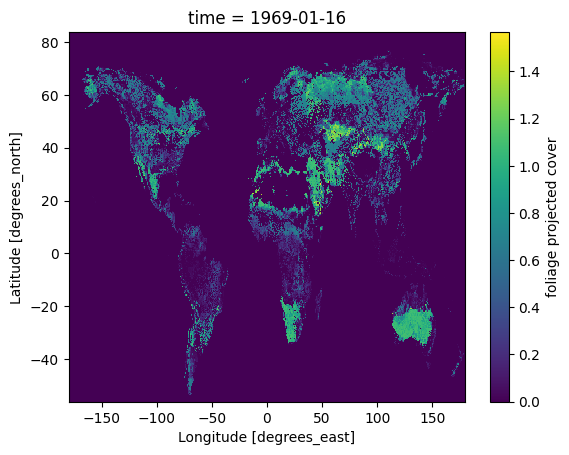

In [15]:
shannon.plot()

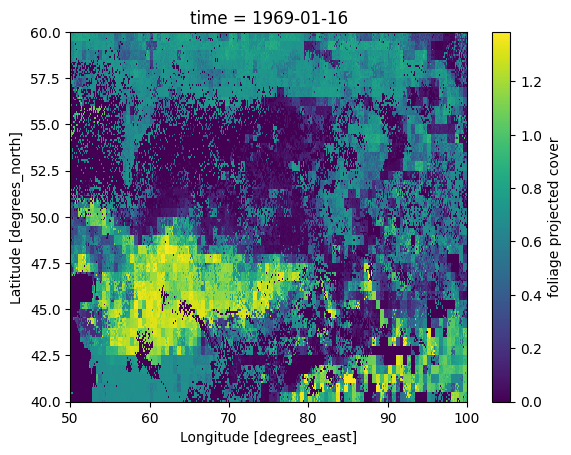

In [17]:
shannon.sel(lon = slice(50,100), lat = slice(40,60)).plot()

In [ ]:
FPC_base[3].plot()

0.91993237


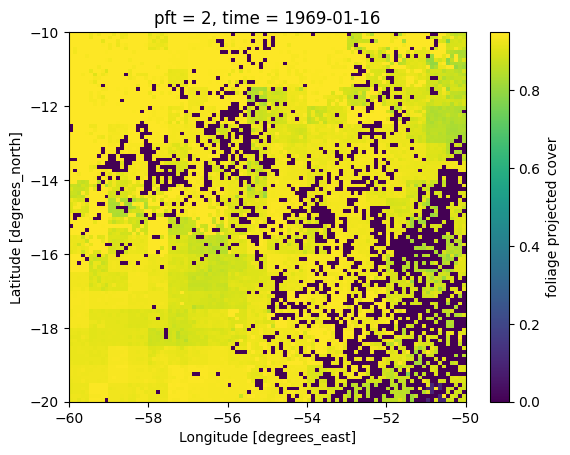

0.03006389


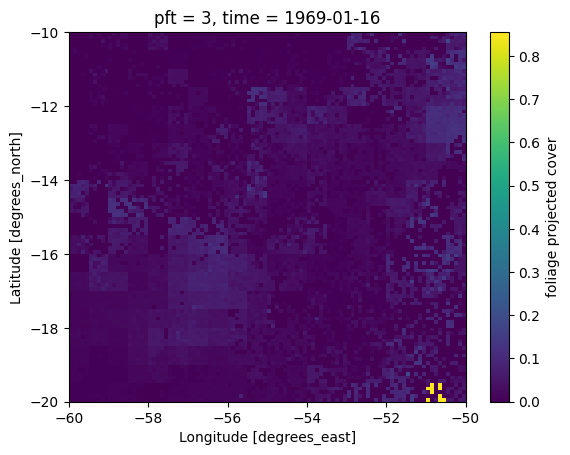

3.7729706e-06


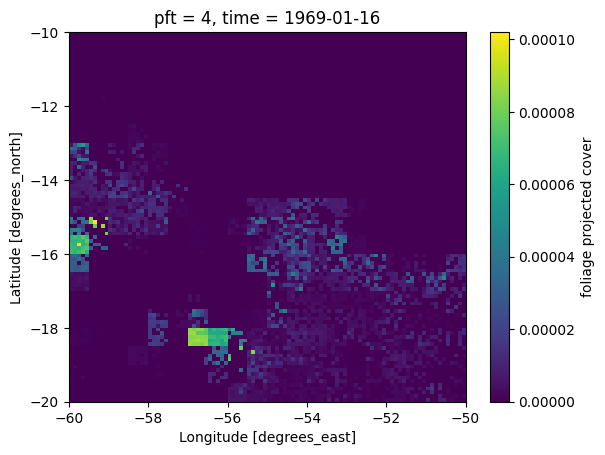

0.0


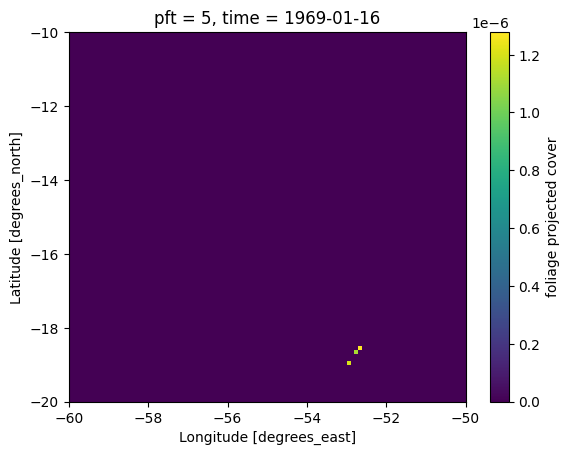

0.0


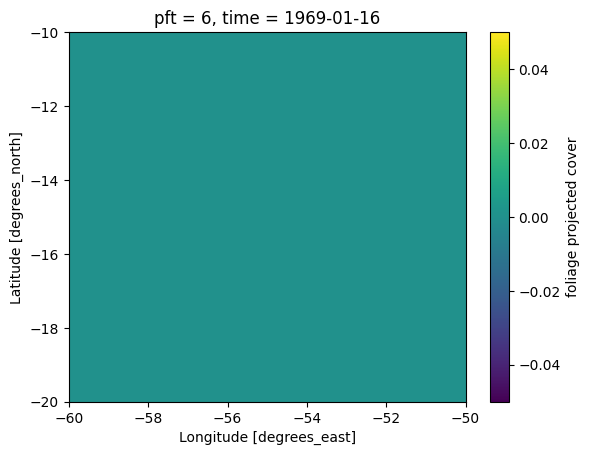

0.0


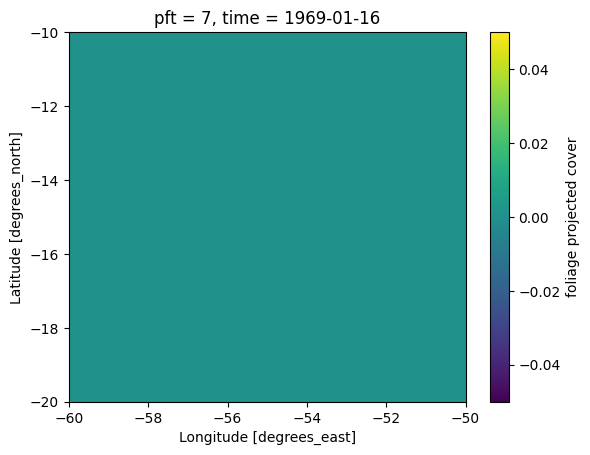

0.0


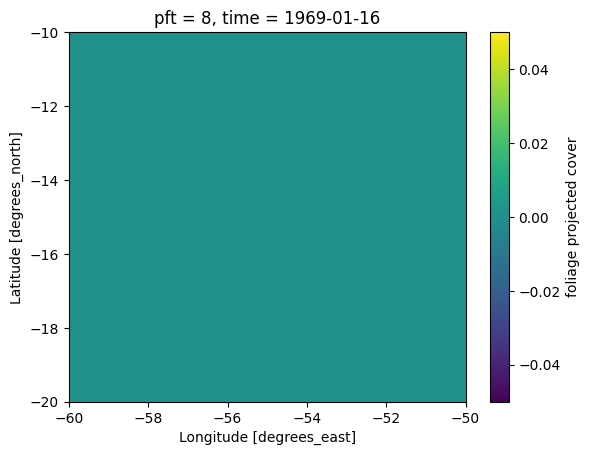

In [4]:
for i in range(0,7):    
    FPC_base[i].sel(lon = slice(-60,-50), lat = slice(-20,-10)).plot()
    print(FPC_base[i].sel(lon = -55, lat = -15,  method='nearest').values)
    plt.show()

In [ ]:
(FPC_base[2].sel(lon = slice(-65,-60), lat = slice(-40,-35)) * FPC_base[3].sel(lon = slice(-65,-60), lat = slice(-40,-35)) * FPC_base[4].sel(lon = slice(-65,-60), lat = slice(-40,-35))).sel(lon = slice(-62,61), lat = slice(-36,-35)).plot()

In [ ]:
FPC_base[3].sel(lon = slice(-65,-60), lat = slice(-40,-35)).plot()

In [ ]:
FPC_base[4].sel(lon = slice(-65,-60), lat = slice(-40,-35)).plot()

In [ ]:
FPC_base[6].sel(lon = slice(125,135), lat = slice(62,65)).plot()

In [ ]:
FPC_base[7].sel(lon = slice(125,135), lat = slice(62,65)).plot()

In [ ]:
print(FPC_base[2].sel(lon = -61.25, lat = -35.7, method = "nearest").values)
print(FPC_base[3].sel(lon = -61.25, lat = -35.7, method = "nearest").values)
print(FPC_base[4].sel(lon = -61.25, lat = -35.7, method = "nearest").values)

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm


def plot_fpc_at_point(lon, lat, out_file="fpc_stackplot.png"):

    base_path = "/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years"

    # --- load datasets ---
    def load(path):
        return xr.open_dataset(path).FPC.sel(
            lon=lon, lat=lat, method="nearest"
        ).convert_calendar("standard").sel(time=slice("1970", "1979"))[:, 1:9]

    datasets = {
        "Baseline": load(f"{base_path}/baseline/output/fpc.nc"),
        "MM": load(f"{base_path}/MM/output/fpc.nc"),
        "DM": load(f"{base_path}/DM/output/fpc.nc"),
    }

    # adjust pft indexing
    for k in datasets:
        datasets[k]["pft"] = datasets[k].pft - 2

    # --- PFT names ---
    pft_names = [
        'tropical broadleaved evergreen tree',
        'tropical broadleaved raingreen tree',
        'temperate needleleaved evergreen tree',
        'temperate broadleaved evergreen tree',
        'temperate broadleaved summergreen tree',
        'boreal needleleaved evergreen tree',
        'boreal broadleaved summergreen tree',
        'boreal needleleaved summergreen tree'
        # 'Tropical C4 grass',
        # 'Temperate C3 grass',
        # 'Polar C3 grass'
    ]

    all_pfts = datasets["Baseline"].pft.values
    pft_labels = {p: pft_names[int(p)] for p in all_pfts}

    # --- colors ---
    tropical = [0, 1]
    temperate = [2, 3, 4]
    boreal = [5, 6, 7]
    # grass = [8, 9, 10]

    pft_colors = {}

    greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
    oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
    blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
    # purples = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

    for i, p in enumerate(tropical):
        pft_colors[p] = greens[i]
    for i, p in enumerate(temperate):
        pft_colors[p] = oranges[i]
    for i, p in enumerate(boreal):
        pft_colors[p] = blues[i]
    # for i, p in enumerate(grass):
    #     pft_colors[p] = purples[i]

    # --- plot ---
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    for ax, (name, data) in zip(axes, datasets.items()):

        time = pd.to_datetime(data.time.values)

        stack_data = [
            data.sel(pft=pft).values for pft in all_pfts
        ]

        ax.stackplot(
            time,
            stack_data,
            colors=[pft_colors[p] for p in all_pfts],
            linewidth=0
        )

        ax.set_title(name, loc="left")
        ax.set_ylabel("FPC")
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Time")

    # legend
    handles = [plt.Rectangle((0, 0), 1, 1, color=pft_colors[p]) for p in all_pfts]
    labels = [pft_labels[p] for p in all_pfts]

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, -0.05)
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # --- transparent save ---
    fig.patch.set_alpha(0)
    for ax in axes:
        ax.set_facecolor("none")

    plt.savefig(
        out_file,
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )

    plt.show()

    print(f"Saved figure to: {out_file}")

In [ ]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm


def plot_fpc_at_point(lon, lat, out_file="fpc_stackplot.png"):

    base_path = "/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years"

    # --- load datasets ---
    def load(path):
        return xr.open_dataset(path).FPC.sel(
            lon=lon, lat=lat, method="nearest"
        ).convert_calendar("standard").sel(time=slice("1970", "1979"))[:, 1:9]

    datasets = {
        "Baseline": load(f"{base_path}/baseline/output/fpc.nc"),
        "MM": load(f"{base_path}/MM/output/fpc.nc"),
        "DM": load(f"{base_path}/DM/output/fpc.nc"),
    }

    # adjust pft indexing
    for k in datasets:
        datasets[k]["pft"] = datasets[k].pft - 2

    # --- PFT names ---
    pft_names = [
        'tropical broadleaved evergreen tree',
        'tropical broadleaved raingreen tree',
        'temperate needleleaved evergreen tree',
        'temperate broadleaved evergreen tree',
        'temperate broadleaved summergreen tree',
        'boreal needleleaved evergreen tree',
        'boreal broadleaved summergreen tree',
        'boreal needleleaved summergreen tree'
        # 'Tropical C4 grass',
        # 'Temperate C3 grass',
        # 'Polar C3 grass'
    ]

    all_pfts = datasets["Baseline"].pft.values
    pft_labels = {p: pft_names[int(p)] for p in all_pfts}

    # --- colors ---
    tropical = [0, 1]
    temperate = [2, 3, 4]
    boreal = [5, 6, 7]
    # grass = [8, 9, 10]

    pft_colors = {}

    greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
    oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
    blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
    # purples = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

    for i, p in enumerate(tropical):
        pft_colors[p] = greens[i]
    for i, p in enumerate(temperate):
        pft_colors[p] = oranges[i]
    for i, p in enumerate(boreal):
        pft_colors[p] = blues[i]
    # for i, p in enumerate(grass):
    #     pft_colors[p] = purples[i]

    # --- plot ---
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

    for ax, (name, data) in zip(axes, datasets.items()):

        time = pd.to_datetime(data.time.values)

        stack_data = [
            data.sel(pft=pft).values for pft in all_pfts
        ]

        ax.stackplot(
            time,
            stack_data,
            colors=[pft_colors[p] for p in all_pfts],
            linewidth=0
        )

        ax.set_title(name, loc="left")
        ax.set_ylabel("FPC")
        ax.grid(alpha=0.2)

    axes[-1].set_xlabel("Time")

    # legend
    handles = [plt.Rectangle((0, 0), 1, 1, color=pft_colors[p]) for p in all_pfts]
    labels = [pft_labels[p] for p in all_pfts]

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, -0.05)
    )

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    # --- transparent save ---
    fig.patch.set_alpha(0)
    for ax in axes:
        ax.set_facecolor("none")

    plt.savefig(
        out_file,
        dpi=300,
        bbox_inches="tight",
        transparent=True
    )

    plt.show()

    print(f"Saved figure to: {out_file}")

In [7]:
# plot_fpc_at_point(lon = -61.25, lat = -35.7, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-61_-35.png")
# plot_fpc_at_point(lon = -55, lat = -15, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-55_-15.png")

plot_fpc_at_point(lon = -93, lat = 36, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-93_-36.png")


# plot_fpc_at_point(lon=125.5, lat=63.5, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_125_63.png")
# plot_fpc_at_point(lon = 27.1, lat = 8.5, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_27_8.png")

: 

In [ ]:
plot_fpc_at_point(lon = -55, lat = -15, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-55_-15.png")

In [ ]:
plot_fpc_at_point(lon=-116, lat=40, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-116_40.png")
plot_fpc_at_point(lon=148, lat=-37, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_148_-37.png")
plot_fpc_at_point(lon=92, lat=26, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_92_26.png")
plot_fpc_at_point(lon=-61, lat=-36, out_file="/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_23_global_droughtexp_10years/FPC_-61_-36.png")


In [ ]:
FPC_base = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years/baseline/output/fpc.nc").FPC.sel(lon = -116, lat = 40, method = "nearest").convert_calendar("standard").sel(time=slice("1969", "1979"))[:,1:]
FPC_MM = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years/MM/output/fpc.nc").FPC.sel(lon = -116, lat = 40, method = "nearest").convert_calendar("standard").sel(time=slice("1969", "1979"))[:,1:]
FPC_DM = xr.open_dataset("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years/DM/output/fpc.nc").FPC.sel(lon = -116, lat = 40, method = "nearest").convert_calendar("standard").sel(time=slice("1969", "1979"))[:,1:]
FPC_base['pft'] = FPC_base.pft - 2
FPC_MM['pft'] = FPC_MM.pft - 2
FPC_DM['pft'] = FPC_DM.pft - 2
FPC_base

In [ ]:
# pack your datasets
datasets = {
    "Baseline": FPC_base,
    "MM": FPC_MM,
    "DM": FPC_DM
}

In [ ]:
pft_names = [ 'tropical broadleaved evergreen tree', 'tropical broadleaved raingreen tree', 'temperate needleleaved evergreen tree', 'temperate broadleaved evergreen tree', 'temperate broadleaved summergreen tree', 'boreal needleleaved evergreen tree', 'boreal broadleaved summergreen tree', 'boreal needleleaved summergreen tree', 'Tropical C4 grass', 'Temperate C3 grass', 'Polar C3 grass' ] 
all_pfts = datasets[list(datasets.keys())[0]].pft.values
pft_labels = { pft: pft_names[int(pft)] for pft in all_pfts }
pft_labels

In [ ]:
# define consistent colors for each PFT
# ---- PFT groups ----
tropical = [0, 1]
temperate = [2, 3, 4]
boreal = [5, 6, 7]
grass = [8, 9, 10]

import matplotlib.cm as cm
import numpy as np

pft_colors = {}

# gradients per group
greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
yellows = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

# assign colors
for i, p in enumerate(tropical):
    pft_colors[p] = greens[i]

for i, p in enumerate(temperate):
    pft_colors[p] = oranges[i]

for i, p in enumerate(boreal):
    pft_colors[p] = blues[i]

for i, p in enumerate(grass):
    pft_colors[p] = yellows[i]

pft_colors

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, (name, data) in zip(axes, datasets.items()):

    time = pd.to_datetime(data.time.values)

    stack_data = []

    for pft in all_pfts:
        vals = data.sel(pft=pft).values
        stack_data.append(vals)

    ax.stackplot(
        time,
        stack_data,
        colors=[pft_colors[p] for p in all_pfts],
        linewidth=0
    )

    ax.set_title(name, loc="left")
    ax.set_ylabel("FPC")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Time")

# legend (once)
handles = [plt.Rectangle((0,0),1,1,color=pft_colors[p]) for p in all_pfts]
labels = [pft_labels[p] for p in all_pfts]

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,              # adjust columns as needed
    frameon=False,
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

for ax, (name, data) in zip(axes, datasets.items()):

    time = pd.to_datetime(data.time.values)

    bottom = np.zeros(len(time))

    for pft in all_pfts:  
        vals = data.sel(pft=pft).values

        ax.bar(
            time,
            vals,
            bottom=bottom,
            width=25,   # monthly spacing
            color=pft_colors[pft],
            linewidth=0
        )
        bottom += vals

    ax.set_title(name, loc="left")
    ax.set_ylabel("FPC")
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("Time")

# legend (once)
handles = [plt.Rectangle((0,0),1,1,color=pft_colors[p]) for p in all_pfts]
labels = [pft_labels[p] for p in all_pfts]

fig.legend(handles, labels, loc="center right")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [ ]:
import xarray as xr
from pathlib import Path

BASE_PATH = Path("/projects/prjs2023/chapter3/lpjml_output/2026_04_23_global_droughtexp_10years")

def load_all_runs(file_name, var_name):
    paths = {
        "baseline": BASE_PATH / "baseline/output" / f"{file_name}.nc",
        "MM": BASE_PATH / "MM/output" / f"{file_name}.nc",
        "DM": BASE_PATH / "DM/output" / f"{file_name}.nc",
    }
    
    data = {
        key: xr.open_dataset(path)[var_name].sel(lon = -116, lat = 40, method = "nearest")
        for key, path in paths.items()
    }
    
    return data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load FPC for all scenarios
fpc = load_all_runs("fpc", "FPC")

# process function: skip total PFT (first), spatial mean
def process_fpc_per_pft(data):
    return data.sel(pft=slice(2, 12)).convert_calendar("standard")

# process all scenarios
fpc_proc = {name: process_fpc_per_pft(ds) for name, ds in fpc.items()}

# # determine valid PFTs (non-empty)
# valid_pfts = []
# for pft in list(fpc_proc.values())[0].pft.values:
#     combined = np.concatenate([fpc_proc[name].sel(pft=pft).values for name in fpc_proc])
#     if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
#         valid_pfts.append(pft)



In [ ]:
valid_pfts = []

for pft in list(fpc_proc.values())[0].pft.values:
    is_all_nan = True
    is_all_zero = True

    for ds in fpc_proc.values():
        vals = ds.sel(pft=pft).values  # small slice → safe

        if not np.all(np.isnan(vals)):
            is_all_nan = False

        if not np.all(vals == 0):
            is_all_zero = False

        # early exit → big speedup
        if not is_all_nan and not is_all_zero:
            valid_pfts.append(pft)
            break
valid_pfts

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

runs = list(fpc_proc.keys())

pft_names = [
    'tropical broadleaved evergreen tree',
    'tropical broadleaved raingreen tree',
    'temperate needleleaved evergreen tree',
    'temperate broadleaved evergreen tree',
    'temperate broadleaved summergreen tree',
    'boreal needleleaved evergreen tree',
    'boreal broadleaved summergreen tree',
    'boreal needleleaved summergreen tree',
    'Tropical C4 grass',
    'Temperate C3 grass',
    'Polar C3 grass'
]

all_pfts = fpc_proc[list(fpc_proc.keys())[0]].pft.values

# map each PFT value to its name based on position
pft_labels = {
    pft: pft_names[int(pft) - 2]
    for pft in all_pfts
}

# define consistent colors for each PFT
# ---- PFT groups ----
tropical = [2, 3]
temperate = [4, 5, 6]
boreal = [7, 8, 9]
grass = [10, 11, 12]

import matplotlib.cm as cm
import numpy as np

pft_colors = {}

# gradients per group
greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
yellows = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

# assign colors
for i, p in enumerate(tropical):
    pft_colors[p] = greens[i]

for i, p in enumerate(temperate):
    pft_colors[p] = oranges[i]

for i, p in enumerate(boreal):
    pft_colors[p] = blues[i]

for i, p in enumerate(grass):
    pft_colors[p] = yellows[i]


fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

selected_runs = runs

for ax, run in zip(axes, selected_runs):
    data = fpc_proc[run]
    
    years = data.time.values
    
    # collect data per PFT
    stack_data = []
    labels = []
    colors = []
    
    for pft in valid_pfts:
        vals = data.sel(pft=pft).values
        stack_data.append(vals)
        labels.append(pft_labels[pft])
        colors.append(pft_colors[pft])
    
    # stacked area plot
    ax.stackplot(years, stack_data, labels=labels, colors=colors)
    
    ax.set_title(run, loc="left")
    ax.set_ylabel("FPC")
    ax.grid(alpha=0.3)

# shared x-label
axes[-1].set_xlabel("Year")

# legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

plt.tight_layout(rect=[0, 0, 0.85, 1])
# plt.savefig(
#     "/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_07_drought_experiment/10years/2026_04_20_tenyeardrought_FPC.png",
#     dpi=300,
#     bbox_inches="tight",
#     transparent=True
# )
plt.show()

In [ ]:
gpp = load_all_runs("pft_gpp", "GPP")

In [ ]:
fpc = load_all_runs("fpc", "FPC")

baseline_nodrought_FPC = fpc["baseline_nodrought"]
DM_nodrought_FPC = fpc["DM_nodrought"]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def process_gpp_per_pft(data):
    return data.sel(pft=slice(1, 12)).convert_calendar("standard")

# process all scenarios automatically
gpp_proc = {name: process_gpp_per_pft(ds) for name, ds in gpp.items()}

# find valid PFTs
valid_pfts = []
for pft in list(gpp_proc.values())[0].pft.values:
    combined = np.concatenate([
        gpp_proc[name].sel(pft=pft).values for name in gpp_proc
    ])
    
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

# create subplots dynamically
n = len(valid_pfts)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5*n), sharex=True)
axes = np.atleast_1d(axes)

for i, pft in enumerate(valid_pfts):
    ax = axes[i]

    for name, data in gpp_proc.items():
        if name.endswith("nodrought"):
            linestyle = "-"      # solid for no drought
        elif name.endswith("drought"):
            linestyle = "--"     # dashed for drought
        else:
            linestyle = "-"      # fallback
        ax.plot(data.time, data.sel(pft=pft), linestyle=linestyle, label=name)

    ax.set_title(f"PFT {pft}", loc="left")
    ax.grid(alpha=0.3)

# labels
fig.supxlabel("Time")
fig.supylabel("GPP (gC/m²/month)")
fig.suptitle("GPP per active PFT (1–12), Spatial Mean")

# legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load FPC for all scenarios
fpc = load_all_runs("fpc", "FPC")

# process function: skip total PFT (first), spatial mean
def process_fpc_per_pft(data):
    return data.sel(pft=slice(2, 12)).convert_calendar("standard")

# process all scenarios
fpc_proc = {name: process_fpc_per_pft(ds) for name, ds in fpc.items()}

# determine valid PFTs (non-empty)
valid_pfts = []
for pft in list(fpc_proc.values())[0].pft.values:
    combined = np.concatenate([fpc_proc[name].sel(pft=pft).values for name in fpc_proc])
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

# create dynamic vertical subplots
n = len(valid_pfts)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5*n), sharex=True)
axes = np.atleast_1d(axes)

for i, pft in enumerate(valid_pfts):
    ax = axes[i]
    
    for name, data in fpc_proc.items():
        if name.endswith("nodrought"):
            linestyle = "-"      # solid for no drought
        elif name.endswith("drought"):
            linestyle = "--"     # dashed for drought
        else:
            linestyle = "-"      # fallback
        ax.plot(data.time, data.sel(pft=pft), linestyle=linestyle, label=name)
    
    ax.set_title(f"PFT {pft - 1}", loc="left")  # subtract 1 because we skipped the total
    ax.grid(alpha=0.3)

# labels and title
fig.supxlabel("Time")
fig.supylabel("FPC")
fig.suptitle("FPC per active PFT (2–12), Spatial Mean (skipping total)")

# legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load NIND for all scenarios
nind = load_all_runs("pft_nind", "nind")

# processing function: first 12 PFTs, spatial mean
def process_nind_per_pft(data):
    return data.sel(pft=slice(1, 12)).convert_calendar("standard")

# process all scenarios
nind_proc = {}
for name, ds in nind.items():
    proc = process_nind_per_pft(ds)
    
    # if baseline runs, sum monthly -> yearly
    if "baseline" in name:
        proc = proc.resample(time="YS").sum()
    
    nind_proc[name] = proc

# determine valid PFTs (non-empty)
valid_pfts = []
for pft in list(nind_proc.values())[0].pft.values:
    combined = np.concatenate([nind_proc[name].sel(pft=pft).values for name in nind_proc])
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

# create vertical subplots dynamically
n = len(valid_pfts)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.5*n), sharex=True)
axes = np.atleast_1d(axes)

for i, pft in enumerate(valid_pfts):
    ax = axes[i]
    
    for name, data in nind_proc.items():
        # precise linestyle: solid = no drought, dashed = drought
        if name.endswith("nodrought"):
            linestyle = "-"
        elif name.endswith("drought"):
            linestyle = "--"
        else:
            linestyle = "-"
        ax.plot(data.time, data.sel(pft=pft), linestyle=linestyle, label=name)
    
    ax.set_title(f"PFT {pft}", loc="left")
    ax.grid(alpha=0.3)

# labels and title
fig.supxlabel("Time")
fig.supylabel("NIND")
fig.suptitle("NIND per active PFT (1–12), Spatial Mean")

# legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
valid_pfts = []
for pft in list(gpp_proc.values())[0].pft.values:
    combined = np.concatenate([
        gpp_proc[name].sel(pft=pft).values for name in gpp_proc
    ])
    
    if not (np.all(np.isnan(combined)) or np.all(np.isclose(combined, 0))):
        valid_pfts.append(pft)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

runs = list(gpp_proc.keys())

pft_names = [
    'tropical broadleaved evergreen tree',
    'tropical broadleaved raingreen tree',
    'temperate needleleaved evergreen tree',
    'temperate broadleaved evergreen tree',
    'temperate broadleaved summergreen tree',
    'boreal needleleaved evergreen tree',
    'boreal broadleaved summergreen tree',
    'boreal needleleaved summergreen tree',
    'Tropical C4 grass',
    'Temperate C3 grass',
    'Polar C3 grass'
]

all_pfts = nind_proc[list(nind_proc.keys())[0]].pft.values

# map each PFT value to its name based on position
pft_labels = {
    pft: pft_names[int(pft) - 1]
    for pft in all_pfts
}

# define consistent colors for each PFT
# ---- PFT groups ----
tropical = [1, 2]
temperate = [3, 4, 5]
boreal = [6, 7, 8]
grass = [9, 10, 11]

import matplotlib.cm as cm
import numpy as np

pft_colors = {}

# gradients per group
greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
yellows = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

# assign colors
for i, p in enumerate(tropical):
    pft_colors[p] = greens[i]

for i, p in enumerate(temperate):
    pft_colors[p] = oranges[i]

for i, p in enumerate(boreal):
    pft_colors[p] = blues[i]

for i, p in enumerate(grass):
    pft_colors[p] = yellows[i]


fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

selected_runs = runs[3:6]  # pick exactly 3 runs

for ax, run in zip(axes, selected_runs):
    data = gpp_proc[run]
    
    years = data.time.values
    
    # collect data per PFT
    stack_data = []
    labels = []
    colors = []
    
    for pft in valid_pfts:
        vals = data.sel(pft=pft).values
        stack_data.append(vals)
        labels.append(pft_labels[pft])
        colors.append(pft_colors[pft])
    
    # stacked area plot
    ax.stackplot(years, stack_data, labels=labels, colors=colors)
    
    ax.set_title(run, loc="left")
    ax.set_ylabel("GPP")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 175)  

# shared x-label
axes[-1].set_xlabel("Year")

# legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

runs = list(nind_proc.keys())

pft_names = [
    'tropical broadleaved evergreen tree',
    'tropical broadleaved raingreen tree',
    'temperate needleleaved evergreen tree',
    'temperate broadleaved evergreen tree',
    'temperate broadleaved summergreen tree',
    'boreal needleleaved evergreen tree',
    'boreal broadleaved summergreen tree',
    'boreal needleleaved summergreen tree',
    'Tropical C4 grass',
    'Temperate C3 grass',
    'Polar C3 grass'
]

all_pfts = nind_proc[list(nind_proc.keys())[0]].pft.values

# map each PFT value to its name based on position
pft_labels = {
    pft: pft_names[int(pft) - 1]
    for pft in all_pfts
}

# define consistent colors for each PFT
# ---- PFT groups ----
tropical = [1, 2]
temperate = [3, 4, 5]
boreal = [6, 7, 8]
grass = [9, 10, 11]

import matplotlib.cm as cm
import numpy as np

pft_colors = {}

# gradients per group
greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
yellows = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

# assign colors
for i, p in enumerate(tropical):
    pft_colors[p] = greens[i]

for i, p in enumerate(temperate):
    pft_colors[p] = oranges[i]

for i, p in enumerate(boreal):
    pft_colors[p] = blues[i]

for i, p in enumerate(grass):
    pft_colors[p] = yellows[i]


fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

selected_runs = runs[3:6]  # pick exactly 3 runs

for ax, run in zip(axes, selected_runs):
    data = nind_proc[run]
    
    years = data.time.values
    
    # collect data per PFT
    stack_data = []
    labels = []
    colors = []
    
    for pft in valid_pfts:
        vals = data.sel(pft=pft).values
        stack_data.append(vals)
        labels.append(pft_labels[pft])
        colors.append(pft_colors[pft])
    
    # stacked area plot
    ax.stackplot(years, stack_data, labels=labels, colors=colors)
    
    ax.set_title(run, loc="left")
    ax.set_ylabel("NIND")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 2.5)

# shared x-label
axes[-1].set_xlabel("Year")

# legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

runs = list(fpc_proc.keys())

pft_names = [
    'tropical broadleaved evergreen tree',
    'tropical broadleaved raingreen tree',
    'temperate needleleaved evergreen tree',
    'temperate broadleaved evergreen tree',
    'temperate broadleaved summergreen tree',
    'boreal needleleaved evergreen tree',
    'boreal broadleaved summergreen tree',
    'boreal needleleaved summergreen tree',
    'Tropical C4 grass',
    'Temperate C3 grass',
    'Polar C3 grass'
]

all_pfts = fpc_proc[list(fpc_proc.keys())[0]].pft.values

# map each PFT value to its name based on position
pft_labels = {
    pft: pft_names[int(pft) - 2]
    for pft in all_pfts
}

# define consistent colors for each PFT
# ---- PFT groups ----
tropical = [2, 3]
temperate = [4, 5, 6]
boreal = [7, 8, 9]
grass = [10, 11, 12]

import matplotlib.cm as cm
import numpy as np

pft_colors = {}

# gradients per group
greens = cm.Greens(np.linspace(0.5, 0.9, len(tropical)))
oranges = cm.Oranges(np.linspace(0.5, 0.9, len(temperate)))
blues = cm.Blues(np.linspace(0.5, 0.9, len(boreal)))
yellows = cm.Purples(np.linspace(0.4, 0.8, len(grass)))

# assign colors
for i, p in enumerate(tropical):
    pft_colors[p] = greens[i]

for i, p in enumerate(temperate):
    pft_colors[p] = oranges[i]

for i, p in enumerate(boreal):
    pft_colors[p] = blues[i]

for i, p in enumerate(grass):
    pft_colors[p] = yellows[i]


fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

selected_runs = runs[3:6]  # pick exactly 3 runs

for ax, run in zip(axes, selected_runs):
    data = fpc_proc[run]
    
    years = data.time.values
    
    # collect data per PFT
    stack_data = []
    labels = []
    colors = []
    
    for pft in valid_pfts:
        vals = data.sel(pft=pft).values
        stack_data.append(vals)
        labels.append(pft_labels[pft])
        colors.append(pft_colors[pft])
    
    # stacked area plot
    ax.stackplot(years, stack_data, labels=labels, colors=colors)
    
    ax.set_title(run, loc="left")
    ax.set_ylabel("FPC")
    ax.grid(alpha=0.3)

# shared x-label
axes[-1].set_xlabel("Year")

# legend (only once)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right")

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig(
    "/home/druijsch/LPJmL5/dev15oct2025/config_files/2026_04_07_drought_experiment/10years/2026_04_20_tenyeardrought_FPC.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
plt.show()